# VMD-TCN-LSTM-MHA Residual Analysis

## Table of Contents
* [Requirements](#requirements)
* [Data Setup](#data-setup)
* [Visual Analysis](#visual-analysis)
    * [Residuals by IMF](#residuals-by-imf)
    * [Recomposed Residuals](#recomposed-residuals)
        * [Actual vs. Predicted](#actual-vs.-predicted)
        * [Distribution of Residuals by Day of the Week](#distribution-of-residuals-by-day-of-the-week)
        * [Distribution of Residuals by Hour of the Day](#distribution-of-residuals-by-hour-of-the-day)
        * [ACF/PACF of Squared Residuals](#acf/pacf-of-squared-residuals)

----

## Requirements

In [15]:
import sys
from pathlib import Path
from joblib import load

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

----

## Data Setup

In [16]:
df_train = pd.read_pickle('../data/processed/df_train.pkl')
df_test = pd.read_pickle('../data/processed/df_test.pkl').iloc[24*7*4:]

df_test_price = df_test[['price']]
df_test_imf = pd.read_pickle('../data/processed/df_test_imf.pkl').iloc[24*7*4:]

df_test_imf_pred = load('../data/predictions/df_test_pred_vtlm.pkl')
df_test_price_pred = df_test_imf_pred.copy(deep=True)
df_test_price_pred['price'] = df_test_price_pred.sum(axis=1)
df_test_price_pred = df_test_price_pred[['price']]

df_price_resid = df_test_price - df_test_price_pred
df_imf_resid = df_test_imf - df_test_imf_pred

dt_index = df_test_price.index

----

## Visual Analysis

### Residuals by IMF

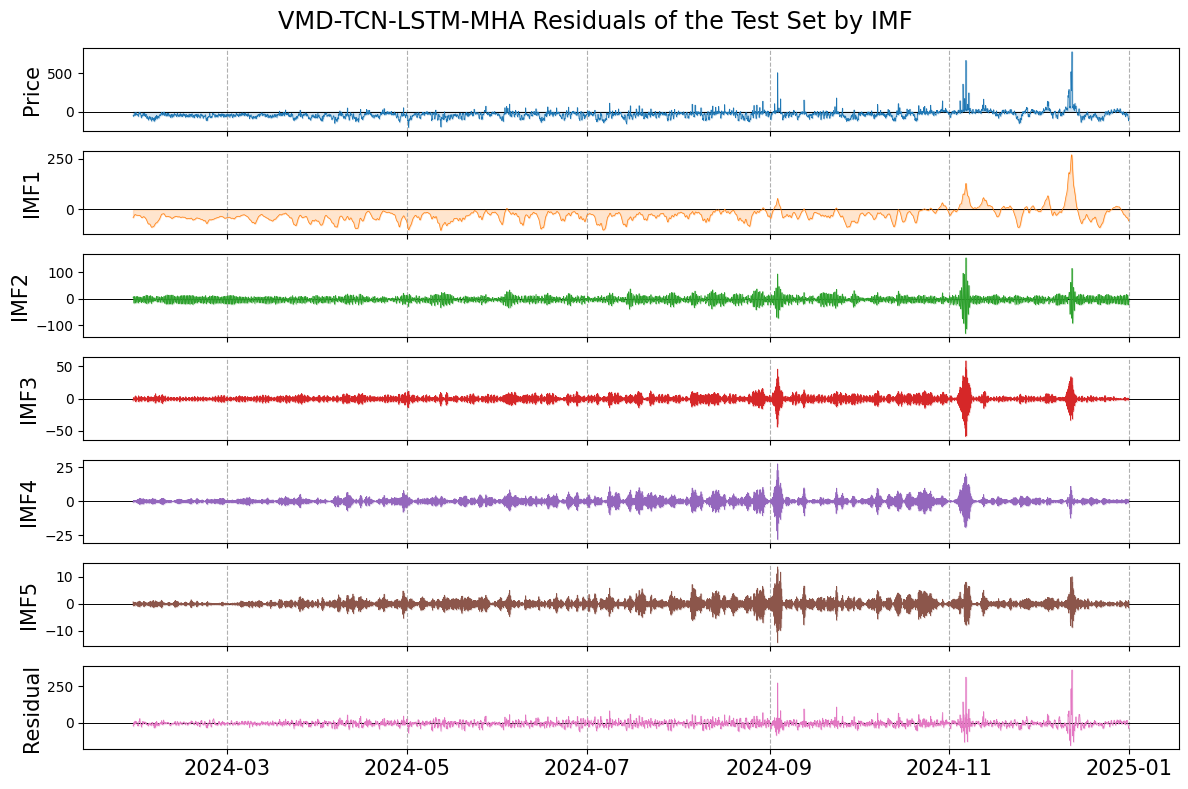

In [17]:
fig, axes = plt.subplots(7, sharex=True, figsize=(12, 8))
colors = plt.colormaps['tab10'].colors

ax = axes[0]
ax.axhline(0, linewidth=0.7, color='black')
ax.plot(df_price_resid.index, df_price_resid['price'], linewidth=0.5, c=colors[0])
ax.fill_between(df_price_resid.index, df_price_resid['price'], color=colors[0], alpha=0.2)
ax.grid(axis='x', linestyle='--')
ax.set_ylabel('Price', fontsize=15)
ax.tick_params(axis='x', labelsize=15)

for i, col in enumerate(df_imf_resid.columns):
    ax = axes[i+1]
    ax.axhline(0, linewidth=0.7, color='black')
    ax.plot(df_imf_resid.index, df_imf_resid[col], linewidth=0.5, c=colors[i+1])
    ax.fill_between(df_price_resid.index, df_imf_resid[col], color=colors[i+1], alpha=0.2)
    ax.grid(axis='x', linestyle='--')
    ax.set_ylabel('Residual' if col=='resid' else col.upper(), fontsize=15)
    ax.tick_params(axis='x', labelsize=15)

fig.suptitle('VMD-TCN-LSTM-MHA Residuals of the Test Set by IMF', fontsize='xx-large')
plt.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_imf_resids.svg')
plt.show()

### Recomposed Residuals

#### Actual vs. Predicted

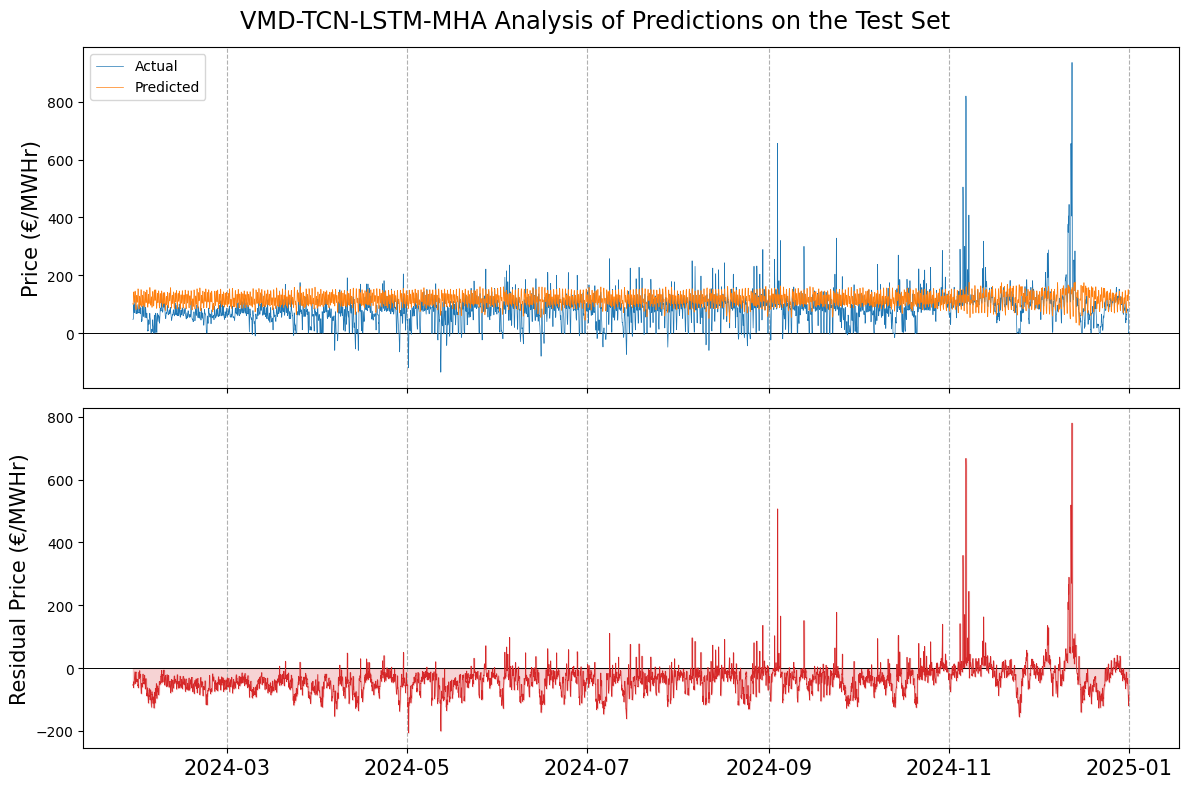

In [91]:
fig, (ax0, ax1) = plt.subplots(2, sharex=True, figsize=(12, 8))

ax0.axhline(0, linewidth=0.7, color='black')
ax0.grid(axis='x', linestyle='--')
ax0.set_ylabel('Price (€/MWHr)', fontsize=15)

ax0.plot(dt_index, df_test_price['price'], linewidth=0.5, c='tab:blue', label='Actual')
ax0.plot(dt_index, df_test_price_pred['price'], linewidth=0.5, c='tab:orange', label='Predicted')
ax0.legend()

ax1.axhline(0, linewidth=0.7, color='black')
ax1.grid(axis='x', linestyle='--')
ax1.set_ylabel('Residual Price (€/MWHr)', fontsize=15)

ax1.plot(dt_index, df_price_resid['price'], linewidth=0.5, c='tab:red')
ax1.fill_between(dt_index, df_test_price['price']-df_test_price_pred['price'], color='tab:red', alpha=0.2)

ax1.tick_params(axis='x', labelsize=15)
fig.suptitle('VMD-TCN-LSTM-MHA Analysis of Predictions on the Test Set', fontsize='xx-large')
plt.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_preds.svg')
plt.show()

#### Distribution of Residuals by Day of the Week

In [19]:
df_price_resid['day_of_week'] = df_price_resid.index.dayofweek
df_price_resid = df_price_resid.replace({0:'Mon', 1:'Tues', 2:'Wed', 3:'Thurs', 4:'Fri', 5:'Sat', 6:'Sun'})

df_price_resid['hour_of_day'] = df_price_resid.index.hour
df_price_resid['hour_of_day'] = df_price_resid['hour_of_day'].astype('str')

df_price_resid.head()

,price,day_of_week,hour_of_day
datetime,,,
2024-01-29 00:00:00+00:00,-54.656222,Mon,0
2024-01-29 01:00:00+00:00,-51.057765,Mon,1
2024-01-29 02:00:00+00:00,-51.883127,Mon,2
2024-01-29 03:00:00+00:00,-56.831102,Mon,3
2024-01-29 04:00:00+00:00,-62.074468,Mon,4


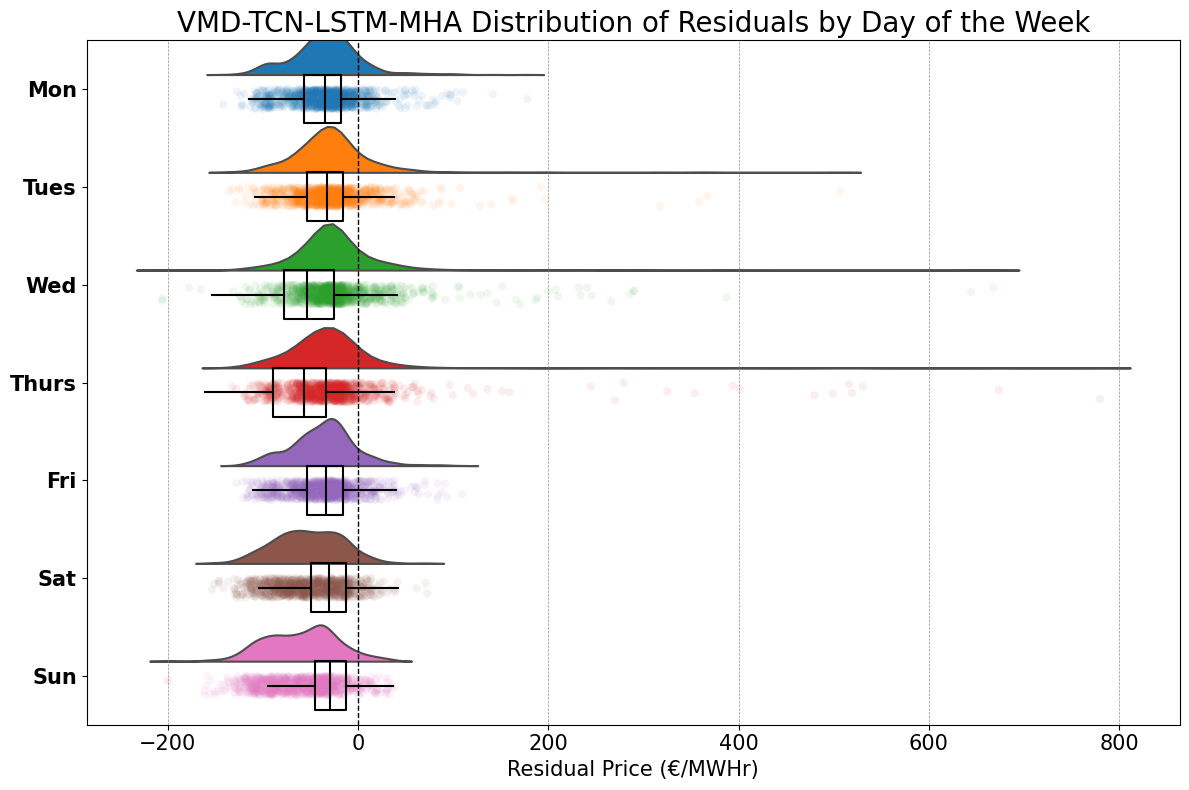

In [ ]:
medianprops = {'linewidth':1.5, 'color':'black', 'solid_capstyle':'butt'}
boxprops = {'linewidth':1.5, 'color':'black'}
group_var = 'day_of_week'
GROUPS = df_price_resid[group_var].unique()
COLORS = plt.colormaps['tab10'].colors

fig, ax = plt.subplots(figsize=(12, 8))

for x in [-200, 200, 400, 600, 800]:
    ax.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.9)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

pt.half_violinplot(
    x='price', y=group_var, scale = 'area', 
    palette='tab10', inner=None, data=df_price_resid, width=1,
    ax=ax
)

for i, group in enumerate(GROUPS):
    data = df_price_resid[df_price_resid[group_var] == group]
    y = i + np.random.uniform(high=0.2, size=len(data))
    x = data['price']
    ax.scatter(x, y, color=COLORS[i%len(COLORS)], edgecolors='none', alpha=0.075)

SHIFT = 0.1
POSITIONS = [_+SHIFT for _ in range(len(GROUPS))]
grouped = df_price_resid.groupby(group_var)['price']
data = [group.values for _, group in grouped]

ax.boxplot(
    data, 
    vert=False, 
    positions=POSITIONS, 
    manage_ticks=False,
    showfliers = False,
    showcaps = False,
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops
)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='both', labelsize=15)
ax.set_xlabel('Residual Price (€/MWHr)', fontsize=15)
ax.set_title('VMD-TCN-LSTM-MHA Distribution of Residuals by Day of the Week', fontsize=20)
fig.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_resid_by_day.svg')
plt.show()

#### Distribution of Residuals by Hour of the Day

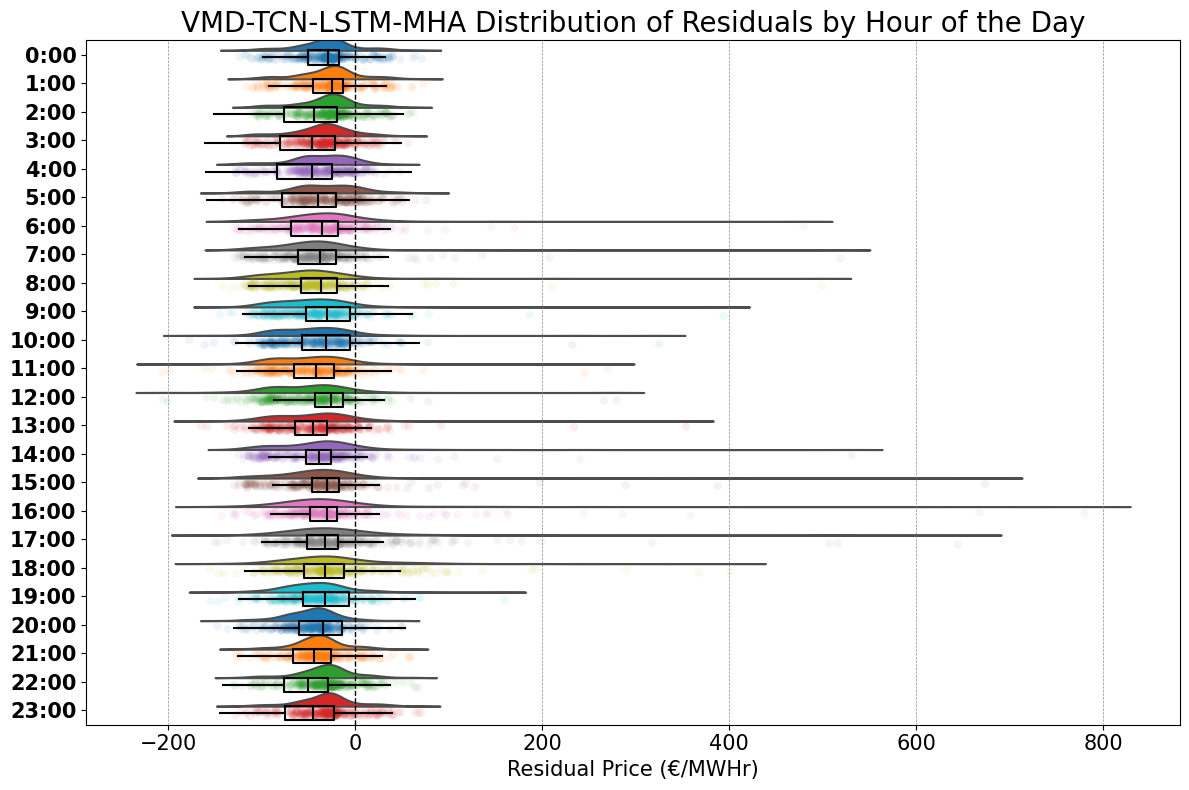

In [ ]:
medianprops = {'linewidth':1.5, 'color':'black', 'solid_capstyle':'butt'}
boxprops = {'linewidth':1.5, 'color':'black'}
group_var = 'hour_of_day'
GROUPS = df_price_resid[group_var].unique()
COLORS = plt.colormaps['tab10'].colors

fig, ax = plt.subplots(figsize=(12, 8))

for x in [-200, 200, 400, 600, 800]:
    ax.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.9)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

pt.half_violinplot(
    x='price', y=group_var, scale = 'area', 
    palette='tab10', inner=None, data=df_price_resid, width=1,
    ax=ax
)

for i, group in enumerate(GROUPS):
    data = df_price_resid[df_price_resid[group_var] == group]
    y = i + np.random.uniform(high=0.2, size=len(data))
    x = data['price']
    ax.scatter(x, y, color=COLORS[i%len(COLORS)], edgecolors='none', alpha=0.075)

SHIFT = 0.1
POSITIONS = [_+SHIFT for _ in range(len(GROUPS))]
grouped = df_price_resid.groupby(group_var)['price']
data = [group.values for _, group in grouped]

ax.boxplot(
    data, 
    vert=False, 
    positions=POSITIONS, 
    manage_ticks=False,
    showfliers = False,
    showcaps = False,
    medianprops = medianprops,
    whiskerprops = boxprops,
    boxprops = boxprops
)

ax.set_yticklabels([str(t)+':00' for t in range(0, 24)])
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='both', labelsize=15)
ax.set_xlabel('Residual Price (€/MWHr)', fontsize=15)
ax.set_title('VMD-TCN-LSTM-MHA Distribution of Residuals by Hour of the Day', fontsize=20)
fig.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_resid_by_hour.svg')
plt.show()

#### ACF/PACF of Squared Residuals

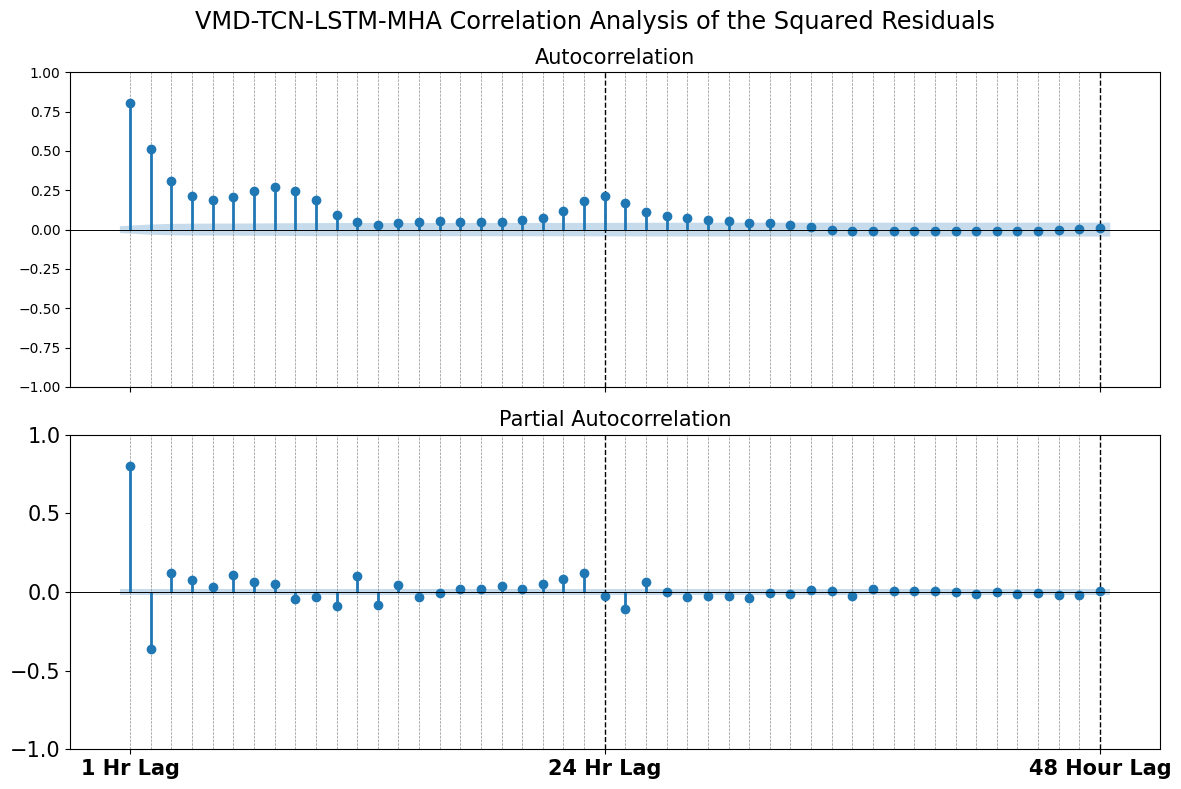

In [134]:
num_days = 2

def grid_lines(ax):
    # ax.vlines([_ for _ in range(0, 24*7*4+1, 24*7)], -1, 1, color='black', linestyle='--', linewidth=0.5)
    ax.vlines([_ for _ in range(1, 24*num_days+1, 1)], -1, 1, color='gray', linestyle='--', alpha=0.2)

sq_resids = df_price_resid['price'].to_numpy()*df_price_resid['price'].to_numpy()

fig, (ax0, ax1) = plt.subplots(2, sharex=True, figsize=(12, 8))

for x in [t for t in range(24*num_days+1) if t%24 != 0]:
    ax0.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.9)
for x in [24, 48]:
    ax0.axvline(x, color='black', linewidth=1, linestyle='--')
plot_acf(sq_resids, ax=ax0, lags=[_ for _ in range(1, 24*num_days+1)], linewidth=0, vlines_kwargs={'linewidth':2}, markersize=6)
ax0.axhline(0, color='black', linewidth=0.7)
ax0.set_title('Autocorrelation', fontsize=15)

for x in [t for t in range(24*num_days+1) if t%24 != 0]:
    ax1.axvline(x, color='gray', linestyle='--', linewidth=0.5, alpha=0.9)
for x in [24, 48]:
    ax1.axvline(x, color='black', linewidth=1, linestyle='--')
plot_pacf(sq_resids, ax=ax1, lags=[_ for _ in range(1, 24*num_days+1)], linewidth=0, vlines_kwargs={'linewidth':2}, markersize=6)
ax1.axhline(0, color='black', linewidth=0.7)
ax1.set_xticks([1, 24, 48])
ax1.set_xticklabels(['1 Hr Lag'] + ['24 Hr Lag'] + ['48 Hour Lag'])
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
ax1.tick_params(axis='both', labelsize=15)
ax1.set_title('Partial Autocorrelation', fontsize=15)

fig.suptitle('VMD-TCN-LSTM-MHA Correlation Analysis of the Squared Residuals', fontsize='xx-large')
fig.tight_layout()
fig.savefig('../results/figures/predictions/vtlm_acf_pacf_sq_resids.svg')
plt.show()